EDA & Correlation

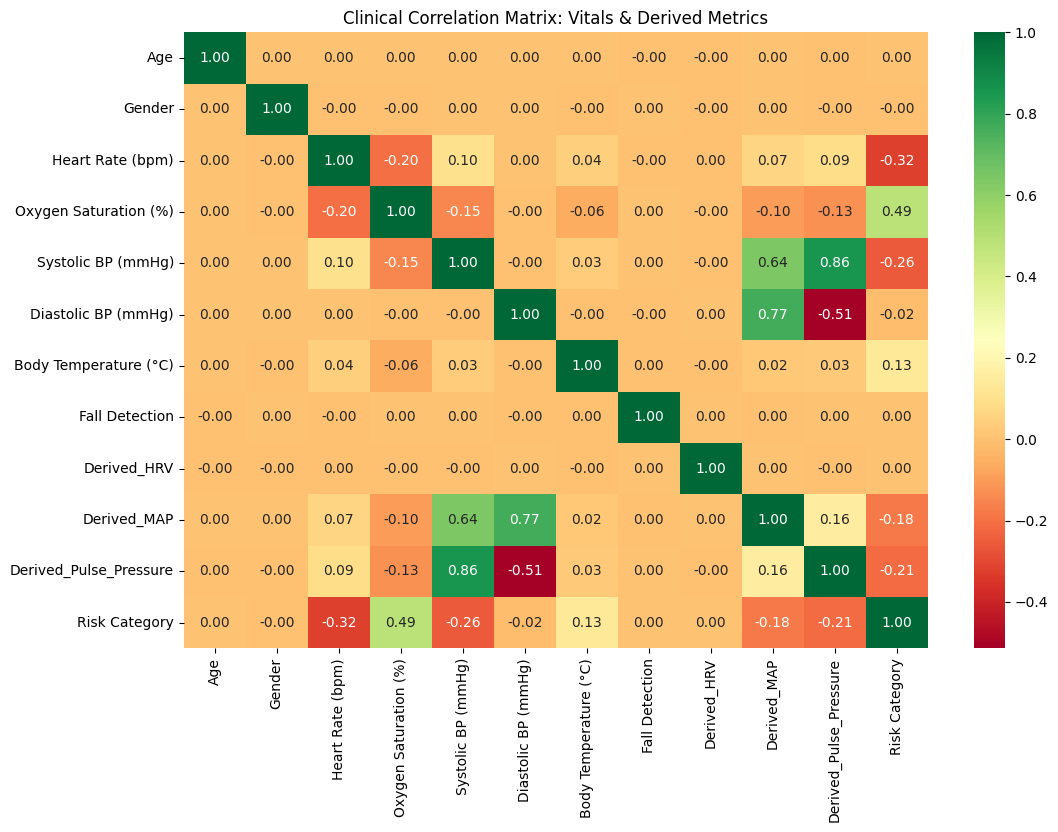

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('ICU_Preprocessed_Data.csv')

# 1. Heatmap for Correlation
plt.figure(figsize=(12, 8))
# Only correlate numeric vitals
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Clinical Correlation Matrix: Vitals & Derived Metrics")
plt.savefig('correlation_heatmap.png')
plt.show()

Evaluation Metrics

In [3]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the "Brain" and the Scaler you saved earlier
model = joblib.load('icu_risk_model.pkl')
scaler = joblib.load('scaler.pkl')

# 2. Prepare the data exactly as you did for training
df = pd.read_csv('ICU_Preprocessed_Data.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Fall Detection'] = le.fit_transform(df['Fall Detection'])
df['Risk_Target'] = le.fit_transform(df['Risk Category'])

# 3. Define the features (Ensure the order matches your training)
features = ['Age', 'Gender', 'Heart Rate (bpm)', 'Oxygen Saturation (%)', 
            'Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 'Body Temperature (°C)', 
            'Fall Detection', 'Derived_HRV', 'Derived_MAP', 'Derived_Pulse_Pressure']

X = df[features]
y = df['Risk_Target']

# 4. Scale and Split (Needed to create X_test and y_test for evaluation)
X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("Success: Model and Test Data are now loaded into memory!")

Success: Model and Test Data are now loaded into memory!


Feature Importance

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26332\3289877800.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


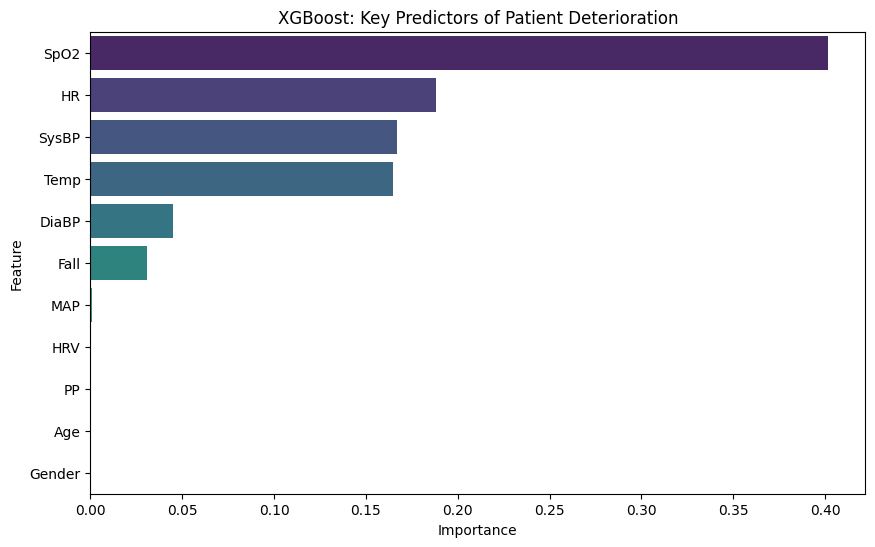

In [3]:
importances = model.feature_importances_
feature_names = ['Age', 'Gender', 'HR', 'SpO2', 'SysBP', 'DiaBP', 'Temp', 'Fall', 'HRV', 'MAP', 'PP']

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title("XGBoost: Key Predictors of Patient Deterioration")
plt.savefig('feature_importance.png')
plt.show()